In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 83.7 MB/s eta 0:00:00



                   DATA ACQUISITION & PREPROCESSING                   
[INFO] 15:25:44 | Accessing directory: AD_graphs
[INFO] 15:26:14 | Accessing directory: LMCI_graphs
[INFO] 15:26:46 | Accessing directory: EMCI_graphs
[INFO] 15:27:19 | Accessing directory: CN_graphs
[INFO] 15:28:26 | Executing SMOTE oversampling for class balance.

                     STRATIFIED K-FOLD VALIDATION                     
[INFO] 15:28:27 | Computational Hardware: cuda
Fold 1 | Epoch 100 | Batch Loss: 0.3573
[STATUS] Fold 1 validation sequence complete.
Fold 2 | Epoch 100 | Batch Loss: 0.3640
[STATUS] Fold 2 validation sequence complete.
Fold 3 | Epoch 100 | Batch Loss: 0.3435
[STATUS] Fold 3 validation sequence complete.
Fold 4 | Epoch 100 | Batch Loss: 0.3468
[STATUS] Fold 4 validation sequence complete.
Fold 5 | Epoch 100 | Batch Loss: 0.3048
[STATUS] Fold 5 validation sequence complete.

                   SYSTEM EVALUATION & ASSET EXPORT                   
System Classification Accuracy: 82.57%
  

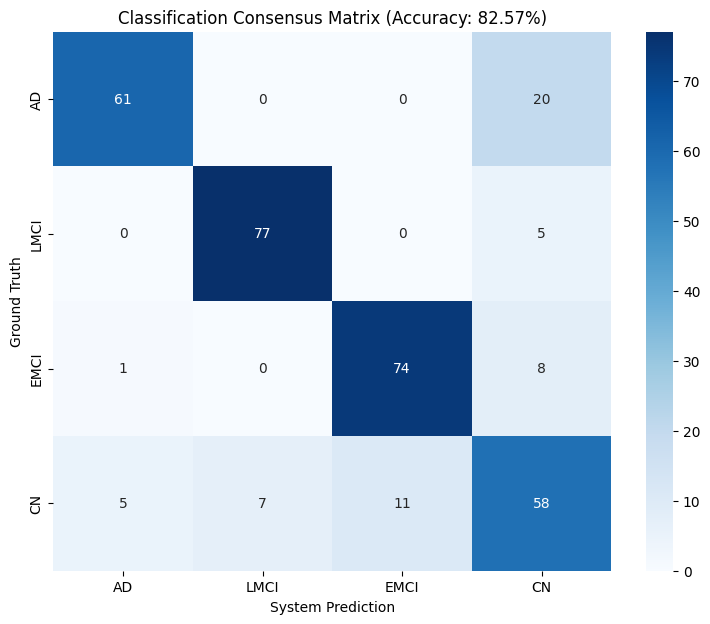

[INFO] 15:34:33 | Exporting model parameters and metadata...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[INFO] 15:34:33 | System execution finalized.


In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime
from torch_geometric.nn import GATv2Conv, AttentionalAggregation, BatchNorm, GraphSizeNorm
from torch_geometric.data import Data
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from google.colab import files

# --- SYSTEM LOGGING UTILITY ---
class ExecutionLogger:
    @staticmethod
    def log_header(title):
        print(f"\n{'='*70}\n{title.center(70)}\n{'='*70}")

    @staticmethod
    def log_info(message):
        print(f"[INFO] {datetime.now().strftime('%H:%M:%S')} | {message}")

    @staticmethod
    def log_status(fold, epoch, loss):
        print(f"\rFold {fold} | Epoch {epoch:03d} | Batch Loss: {loss:.4f}", end="")

# --- CORE ARCHITECTURE: MULTIPLEX CROSS-ATTENTION WITH EXPLAINABILITY ---
class MultiplexCrossAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.query = nn.Linear(in_channels, in_channels)
        self.key = nn.Linear(in_channels, in_channels)
        self.value = nn.Linear(in_channels, in_channels)
        self.scale = np.sqrt(in_channels)

    def forward(self, p, g, w):
        x = torch.stack([p, g, w], dim=1)
        q, k, v = self.query(x), self.key(x), self.value(x)

        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / self.scale
        attn_weights = F.softmax(attn_scores, dim=-1)

        fused_out = torch.matmul(attn_weights, v).mean(dim=1)
        return fused_out, attn_weights

class NeuroVistaGNN(torch.nn.Module):
    def __init__(self, node_in, vector_in):
        super().__init__()
        self.gat_p = GATv2Conv(node_in, 64, heads=8, concat=True)
        self.gat_g = GATv2Conv(node_in, 64, heads=8, concat=True)
        self.gat_w = GATv2Conv(node_in, 64, heads=8, concat=True)

        self.cross_modal_fusion = MultiplexCrossAttention(512)
        self.gnorm, self.bn = GraphSizeNorm(), BatchNorm(512)
        self.pool = AttentionalAggregation(nn.Sequential(nn.Linear(512, 1)))

        self.classifier = nn.Sequential(
            nn.Linear(512 + vector_in, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )

    def forward(self, data, return_attn=False):
        # Capture Attention Weights for Frontend Explainability
        p_x, (p_edge, p_alpha) = self.gat_p(data.x, data.edge_index, return_attention_weights=True)
        g_x, (g_edge, g_alpha) = self.gat_g(data.x, data.edge_granger, return_attention_weights=True)
        w_x, (w_edge, w_alpha) = self.gat_w(data.x, data.edge_wavelet, return_attention_weights=True)

        p, g, w = F.elu(p_x), F.elu(g_x), F.elu(w_x)

        f, modality_weights = self.cross_modal_fusion(p, g, w)
        f = self.bn(self.gnorm(f, data.batch))

        logits = self.classifier(torch.cat([self.pool(f, data.batch), data.extra_feat], dim=1))

        if return_attn:
            xai = {
                "node_importance": {
                    "pearson": p_alpha.mean(dim=1).detach().cpu().numpy(),
                    "granger": g_alpha.mean(dim=1).detach().cpu().numpy(),
                    "wavelet": w_alpha.mean(dim=1).detach().cpu().numpy()
                },
                "modality_weights": modality_weights.mean(dim=0).detach().cpu().numpy()
            }
            return logits, xai

        return logits

# --- DATA PREPARATION PIPELINE ---
class MultiModalBatch:
    def __init__(self, data_list):
        self.x = torch.cat([d.x for d in data_list], 0)
        self.y = torch.cat([d.y for d in data_list], 0)
        self.extra_feat = torch.cat([d.extra_feat for d in data_list], 0)
        self.batch = torch.cat([torch.full((d.num_nodes,), i, dtype=torch.long) for i, d in enumerate(data_list)], 0)
        curr_n, e_p, e_g, e_w = 0, [], [], []
        for d in data_list:
            e_p.append(d.edge_index + curr_n)
            e_g.append(d.edge_granger + curr_n)
            e_w.append(d.edge_wavelet + curr_n)
            curr_n += d.num_nodes
        self.edge_index = torch.cat(e_p, 1)
        self.edge_granger = torch.cat(e_g, 1)
        self.edge_wavelet = torch.cat(e_w, 1)

    def to(self, device):
        self.x, self.y, self.batch, self.extra_feat = self.x.to(device), self.y.to(device), self.batch.to(device), self.extra_feat.to(device)
        self.edge_index, self.edge_granger, self.edge_wavelet = self.edge_index.to(device), self.edge_granger.to(device), self.edge_wavelet.to(device)
        return self

# --- GLOBAL CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_NODES = 116
PCA_DIM = 32
SAMPLING_STRATEGY = {0: 81, 1: 82, 2: 83, 3: 81}
CLASS_LABELS = ['AD', 'LMCI', 'EMCI', 'CN']
BASE_PATH = "/content/drive/MyDrive/NEUROVISTA-PROJECT/All_GRAPHS_Unzipped"

def load_processed_dataset(base_path):
    ExecutionLogger.log_header("DATA ACQUISITION & PREPROCESSING")
    X_raw, y_raw, file_names = [], [], []
    class_map = {'AD_graphs': 0, 'LMCI_graphs': 1, 'EMCI_graphs': 2, 'CN_graphs': 3}

    for folder, val in class_map.items():
        p_path = f"{base_path}/{folder}/Graph_Output"
        if not os.path.exists(p_path): continue
        ExecutionLogger.log_info(f"Accessing directory: {folder}")
        for f in sorted(os.listdir(p_path)):
            sid = f.replace('_corr_matrix.npy', '')
            try:
                p = np.load(f"{p_path}/{f}")
                g = np.load(f"{base_path}/{folder}/Graph_Output_Granger/{sid}_granger_matrix.npy")
                w = np.load(f"{base_path}/{folder}/Graph_Output_Coherence/{sid}_coherence_matrix.npy")
                X_raw.append(np.hstack([p.flatten(), g.flatten(), w.flatten()]))
                y_raw.append(val)
                file_names.append(f"{sid}_timeseries.npy")
            except Exception: continue

    X_raw, y_raw = np.array(X_raw), np.array(y_raw)
    ExecutionLogger.log_info("Executing SMOTE oversampling for class balance.")
    X_res, y_res = SMOTE(sampling_strategy=SAMPLING_STRATEGY, random_state=42).fit_resample(X_raw, y_raw)
    for i in range(len(y_res) - len(file_names)): file_names.append(f"synthetic_{i}.npy")

    scaler = StandardScaler()
    X_norm = scaler.fit_transform(X_res)
    size, ds = NUM_NODES * NUM_NODES, []

    for i in range(len(y_res)):
        p_m = X_res[i, :size].reshape(NUM_NODES, NUM_NODES)
        g_m = X_res[i, size:2*size].reshape(NUM_NODES, NUM_NODES)
        w_m = X_res[i, 2*size:].reshape(NUM_NODES, NUM_NODES)
        threshold = np.percentile(np.abs(p_m), 85)

        data_obj = Data(
            x=torch.tensor(p_m[:, :PCA_DIM], dtype=torch.float),
            edge_index=torch.tensor(np.argwhere(np.abs(p_m) > threshold).T, dtype=torch.long),
            edge_granger=torch.tensor(np.argwhere(np.abs(g_m) > threshold).T, dtype=torch.long),
            edge_wavelet=torch.tensor(np.argwhere(np.abs(w_m) > threshold).T, dtype=torch.long),
            y=torch.tensor([y_res[i]], dtype=torch.long),
            extra_feat=torch.tensor(X_norm[i, :1024], dtype=torch.float).view(1, -1),
            num_nodes=NUM_NODES
        )
        data_obj.filename = file_names[i]
        ds.append(data_obj)

    return ds, scaler

# --- MODEL TRAINING ENGINE ---
def execute_training_pipeline():
    dataset, scaler = load_processed_dataset(BASE_PATH)
    labels = [d.y.item() for d in dataset]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    all_preds, all_labels, last_fold_test_files = [], [], []
    loss_weights = torch.tensor([1.0, 1.0, 1.0, 1.4]).to(DEVICE)

    ExecutionLogger.log_header("STRATIFIED K-FOLD VALIDATION")
    ExecutionLogger.log_info(f"Computational Hardware: {DEVICE}")

    for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(dataset)), labels)):
        train_loader = DataLoader([dataset[i] for i in train_idx], batch_size=8, shuffle=True, collate_fn=MultiModalBatch)
        test_loader = DataLoader([dataset[i] for i in test_idx], batch_size=1, collate_fn=MultiModalBatch)

        model = NeuroVistaGNN(PCA_DIM, 1024).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1.2e-4, weight_decay=0.05)
        scheduler = OneCycleLR(optimizer, max_lr=5e-4, steps_per_epoch=len(train_loader), epochs=100)

        for epoch in range(1, 101):
            model.train()
            epoch_loss = 0
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()
                output = model(batch)
                loss = F.cross_entropy(output, batch.y, weight=loss_weights, label_smoothing=0.05)
                loss.backward()
                optimizer.step()
                scheduler.step()
                epoch_loss += loss.item()

            if epoch % 10 == 0:
                ExecutionLogger.log_status(fold+1, epoch, epoch_loss/len(train_loader))

        model.eval()
        with torch.no_grad():
            for batch in test_loader:
                all_preds.append(model(batch.to(DEVICE)).argmax(1).item())
                all_labels.append(batch.y.item())

        if fold == 4:
            last_fold_test_files = [dataset[i].filename for i in test_idx if "synthetic" not in dataset[i].filename]
        print(f"\n[STATUS] Fold {fold+1} validation sequence complete.")

    return model, scaler, all_labels, all_preds, last_fold_test_files

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    trained_model, data_scaler, y_true, y_pred, test_files = execute_training_pipeline()

    ExecutionLogger.log_header("SYSTEM EVALUATION & ASSET EXPORT")
    accuracy = accuracy_score(y_true, y_pred) * 100
    print(f"System Classification Accuracy: {accuracy:.2f}%")
    print(classification_report(y_true, y_pred, target_names=CLASS_LABELS))

    # Confusion Matrix Visualization
    plt.figure(figsize=(9, 7))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
    plt.title(f'Classification Consensus Matrix (Accuracy: {accuracy:.2f}%)')
    plt.ylabel('Ground Truth')
    plt.xlabel('System Prediction')
    plt.show()

    # Asset Serialization with NEW FILE NAMES
    with open("last_fold_test_samples.txt", "w") as f:
        f.write("\n".join(test_files))

    trained_model.to('cpu')
    torch.save(trained_model.state_dict(), 'multiclassification.pth')
    joblib.dump(data_scaler, 'multiclassification_scaler.pkl')

    ExecutionLogger.log_info("Exporting model parameters and metadata...")
    for file_to_download in ['multiclassification.pth', 'multiclassification_scaler.pkl', 'last_fold_test_samples.txt']:
        files.download(file_to_download)
    ExecutionLogger.log_info("System execution finalized.")

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime
from torch_geometric.nn import GATv2Conv, AttentionalAggregation, BatchNorm, GraphSizeNorm
from torch_geometric.data import Data
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# --- SYSTEM LOGGING ---
class NeuroDiagnosticLogger:
    @staticmethod
    def log_header(title):
        print(f"\n{'='*70}\n{title.center(70)}\n{'='*70}")

    @staticmethod
    def log_info(message):
        print(f"[INFO] {datetime.now().strftime('%H:%M:%S')} | {message}")

    @staticmethod
    def log_status(fold, epoch, loss):
        print(f"\rFold {fold} | Epoch {epoch:03d} | Batch Loss: {loss:.4f}", end="")

# --- ARCHITECTURE (Matched to Model A for Seamless Integration) ---
class MultiplexCrossAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.query = nn.Linear(in_channels, in_channels)
        self.key = nn.Linear(in_channels, in_channels)
        self.value = nn.Linear(in_channels, in_channels)
        self.scale = np.sqrt(in_channels)

    def forward(self, p, g, w):
        x = torch.stack([p, g, w], dim=1)
        q, k, v = self.query(x), self.key(x), self.value(x)
        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / self.scale
        attn_weights = F.softmax(attn_scores, dim=-1)
        return torch.matmul(attn_weights, v).mean(dim=1)

class MultiTopologyGNN(torch.nn.Module):
    def __init__(self, node_in=32, vector_in=1024):
        super().__init__()
        self.gat_p = GATv2Conv(node_in, 64, heads=8, concat=True)
        self.gat_g = GATv2Conv(node_in, 64, heads=8, concat=True)
        self.gat_w = GATv2Conv(node_in, 64, heads=8, concat=True)

        self.cross_modal_fusion = MultiplexCrossAttention(512)
        self.gnorm, self.bn = GraphSizeNorm(), BatchNorm(512)
        self.pool = AttentionalAggregation(nn.Sequential(nn.Linear(512, 1)))

        self.classifier = nn.Sequential(
            nn.Linear(512 + vector_in, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2) # Binary Output: 0=sMCI, 1=pMCI
        )

    def forward(self, data):
        p = F.elu(self.gat_p(data.x, data.edge_index))
        g = F.elu(self.gat_g(data.x, data.edge_granger))
        w = F.elu(self.gat_w(data.x, data.edge_wavelet))

        f = self.bn(self.gnorm(self.cross_modal_fusion(p, g, w), data.batch))
        return self.classifier(torch.cat([self.pool(f, data.batch), data.extra_feat], dim=1))

# --- DATA UTILITIES ---
class MultiModalBatch:
    def __init__(self, data_list):
        self.x = torch.cat([d.x for d in data_list], 0)
        self.y = torch.cat([d.y for d in data_list], 0)
        self.extra_feat = torch.cat([d.extra_feat for d in data_list], 0)
        self.batch = torch.cat([torch.full((d.num_nodes,), i, dtype=torch.long) for i, d in enumerate(data_list)], 0)
        curr_n, e_p, e_g, e_w = 0, [], [], []
        for d in data_list:
            e_p.append(d.edge_index + curr_n); e_g.append(d.edge_granger + curr_n); e_w.append(d.edge_wavelet + curr_n)
            curr_n += d.num_nodes
        self.edge_index = torch.cat(e_p, 1); self.edge_granger = torch.cat(e_g, 1); self.edge_wavelet = torch.cat(e_w, 1)

    def to(self, device):
        for attr in ['x', 'y', 'batch', 'extra_feat', 'edge_index', 'edge_granger', 'edge_wavelet']:
            setattr(self, attr, getattr(self, attr).to(device))
        return self

# --- CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_NODES = 116
PCA_DIM = 32
AUX_VECTOR_SIZE = 1024
PATH_TO_DATA = "/content/drive/MyDrive/NEUROVISTA-PROJECT/SMCI_PMCI_LABELED"

def load_prognosis_dataset(base_path):
    NeuroDiagnosticLogger.log_header("PROGNOSIS DATA ACQUISITION")
    X_raw, y_raw = [], []

    for folder, label in [('SMCI', 0), ('pMCI', 1)]:
        p_path = f"{base_path}/{folder}/pearson"
        if not os.path.exists(p_path): continue
        NeuroDiagnosticLogger.log_info(f"Scanning Clinical Group: {folder}")

        for f in sorted(os.listdir(p_path)):
            sid = f.split('_pearson')[0]
            try:
                p = np.load(f"{p_path}/{f}")
                g = np.load(f"{base_path}/{folder}/granger/{sid}_granger.npy")
                c = np.load(f"{base_path}/{folder}/coherence/{sid}_coherence.npy")
                X_raw.append(np.hstack([p.flatten(), g.flatten(), c.flatten()]))
                y_raw.append(label)
            except: continue

    X_raw, y_raw = np.array(X_raw), np.array(y_raw)
    X_res, y_res = SMOTE(random_state=42).fit_resample(X_raw, y_raw)

    scaler = StandardScaler()
    X_norm = scaler.fit_transform(X_res)

    dataset = []
    matrix_dim = NUM_NODES * NUM_NODES
    for i in range(len(y_res)):
        p_m = X_res[i, :matrix_dim].reshape(NUM_NODES, NUM_NODES)
        g_m = X_res[i, matrix_dim:2*matrix_dim].reshape(NUM_NODES, NUM_NODES)
        w_m = X_res[i, 2*matrix_dim:].reshape(NUM_NODES, NUM_NODES)
        thresh = np.percentile(np.abs(p_m), 85)

        data_obj = Data(
            x=torch.tensor(p_m[:, :PCA_DIM], dtype=torch.float),
            edge_index=torch.tensor(np.argwhere(np.abs(p_m) > thresh).T, dtype=torch.long),
            edge_granger=torch.tensor(np.argwhere(np.abs(g_m) > thresh).T, dtype=torch.long),
            edge_wavelet=torch.tensor(np.argwhere(np.abs(w_m) > thresh).T, dtype=torch.long),
            y=torch.tensor([y_res[i]], dtype=torch.long),
            extra_feat=torch.tensor(X_norm[i, :AUX_VECTOR_SIZE], dtype=torch.float).view(1, -1),
            num_nodes=NUM_NODES
        )
        dataset.append(data_obj)

    return dataset, scaler

# --- TRAINING & EVALUATION ---
def run_pipeline():
    dataset, scaler = load_prognosis_dataset(PATH_TO_DATA)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    metrics = {'y_true': [], 'y_pred': [], 'y_prob': []}

    NeuroDiagnosticLogger.log_header("TRAINING PROGNOSTIC ENGINE")

    for fold, (t_idx, v_idx) in enumerate(skf.split(np.zeros(len(dataset)), [d.y.item() for d in dataset])):
        train_loader = DataLoader([dataset[i] for i in t_idx], batch_size=8, shuffle=True, collate_fn=MultiModalBatch)
        val_loader = DataLoader([dataset[i] for i in v_idx], batch_size=1, collate_fn=MultiModalBatch)

        model = MultiTopologyGNN(PCA_DIM, AUX_VECTOR_SIZE).to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
        sched = OneCycleLR(opt, max_lr=4e-4, steps_per_epoch=len(train_loader), epochs=50)

        for epoch in range(1, 51):
            model.train()
            l_sum = 0
            for batch in train_loader:
                batch = batch.to(DEVICE)
                opt.zero_grad()
                out = model(batch)
                loss = F.cross_entropy(out, batch.y.squeeze())
                loss.backward()
                opt.step(); sched.step()
                l_sum += loss.item()
            if epoch % 25 == 0: NeuroDiagnosticLogger.log_status(fold+1, epoch, l_sum/len(train_loader))

        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                logits = model(batch.to(DEVICE))
                probs = F.softmax(logits, dim=1)
                metrics['y_true'].append(batch.y.item())
                metrics['y_pred'].append(logits.argmax(1).item())
                metrics['y_prob'].append(probs[:, 1].cpu().item())

        print(f"\n[FOLD {fold+1} COMPLETE]")

    return model, scaler, metrics

if __name__ == "__main__":
    trained_model, final_scaler, results = run_pipeline()

    # --- EVALUATION ---
    NeuroDiagnosticLogger.log_header("PROGNOSTIC PERFORMANCE REPORT")
    acc = accuracy_score(results['y_true'], results['y_pred']) * 100
    auc = roc_auc_score(results['y_true'], results['y_prob'])
    print(f"Accuracy: {acc:.2f}% | ROC-AUC: {auc:.4f}")
    print(classification_report(results['y_true'], results['y_pred'], target_names=['sMCI', 'pMCI']))

   # ==========================================
# ASSET EXPORT (PTH & PKL)
# ==========================================
NeuroDiagnosticLogger.log_header("FINAL ASSET EXPORT")

# 1. Save Model Weights (.pth)
# We set the model to CPU and eval mode for maximum portability
trained_model.eval()
trained_model.to('cpu')
torch.save(trained_model.state_dict(), "binary_model.pth")
NeuroDiagnosticLogger.log_info("Model weights saved to binary_model.pth")

# 2. Save Preprocessing Scaler and Metadata (.pkl)
# Bundling the scaler and metadata into one file for the backend
export_package = {
    'scaler': final_scaler,
    'metadata': {
        'brain_regions': NUM_NODES,
        'pca_dim': PCA_DIM,
        'aux_vector_size': AUX_VECTOR_SIZE,
        'classes': ['sMCI', 'pMCI'],
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M')
    }
}

joblib.dump(export_package, "binary_model.pkl")
NeuroDiagnosticLogger.log_info("Scaler and metadata saved to binary_model.pkl")

# Trigger Colab Download
try:
    from google.colab import files
    files.download("binary_model.pth")
    files.download("binary_model.pkl")
    NeuroDiagnosticLogger.log_info("System download triggered for both assets.")
except ImportError:
    NeuroDiagnosticLogger.log_info("Files saved locally in the 'content' directory.")


                      PROGNOSIS DATA ACQUISITION                      
[INFO] 05:39:44 | Scanning Clinical Group: SMCI
[INFO] 05:41:44 | Scanning Clinical Group: pMCI

                      TRAINING PROGNOSTIC ENGINE                      
Fold 1 | Epoch 050 | Batch Loss: 0.2015
[FOLD 1 COMPLETE]
Fold 2 | Epoch 050 | Batch Loss: 0.1519
[FOLD 2 COMPLETE]
Fold 3 | Epoch 050 | Batch Loss: 0.1783
[FOLD 3 COMPLETE]
Fold 4 | Epoch 050 | Batch Loss: 0.1556
[FOLD 4 COMPLETE]
Fold 5 | Epoch 050 | Batch Loss: 0.1812
[FOLD 5 COMPLETE]

                    PROGNOSTIC PERFORMANCE REPORT                     
Accuracy: 80.91% | ROC-AUC: 0.9167
              precision    recall  f1-score   support

        sMCI       0.79      0.84      0.81        55
        pMCI       0.83      0.78      0.80        55

    accuracy                           0.81       110
   macro avg       0.81      0.81      0.81       110
weighted avg       0.81      0.81      0.81       110


                          FINAL ASS

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[INFO] 05:43:51 | System download triggered for both assets.



                      PROGNOSIS DATA ACQUISITION                      
[INFO] 15:06:38 | Scanning Clinical Group: SMCI
[INFO] 15:08:46 | Scanning Clinical Group: pMCI

                      TRAINING PROGNOSTIC ENGINE                      
Fold 1 | Epoch 050 | Batch Loss: 0.1932
[FOLD 1 COMPLETE]
Fold 2 | Epoch 050 | Batch Loss: 0.1390
[FOLD 2 COMPLETE]
Fold 3 | Epoch 050 | Batch Loss: 0.1671
[FOLD 3 COMPLETE]
Fold 4 | Epoch 050 | Batch Loss: 0.1394
[FOLD 4 COMPLETE]
Fold 5 | Epoch 050 | Batch Loss: 0.1413
[FOLD 5 COMPLETE]

                    PROGNOSTIC PERFORMANCE REPORT                     
Accuracy: 80.91% | ROC-AUC: 0.9170
              precision    recall  f1-score   support

        sMCI       0.80      0.82      0.81        55
        pMCI       0.81      0.80      0.81        55

    accuracy                           0.81       110
   macro avg       0.81      0.81      0.81       110
weighted avg       0.81      0.81      0.81       110



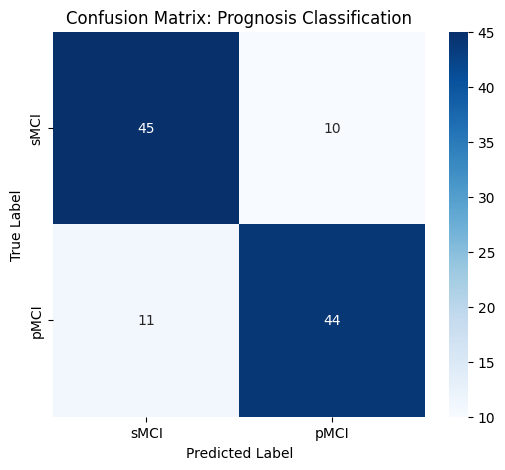


                          FINAL ASSET EXPORT                          
[INFO] 15:10:59 | Model weights saved to binary_model.pth
[INFO] 15:10:59 | Scaler and metadata saved to binary_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[INFO] 15:10:59 | System download triggered for both assets.


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime
from torch_geometric.nn import GATv2Conv, AttentionalAggregation, BatchNorm, GraphSizeNorm
from torch_geometric.data import Data
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# --- SYSTEM LOGGING ---
class NeuroDiagnosticLogger:
    @staticmethod
    def log_header(title):
        print(f"\n{'='*70}\n{title.center(70)}\n{'='*70}")

    @staticmethod
    def log_info(message):
        print(f"[INFO] {datetime.now().strftime('%H:%M:%S')} | {message}")

    @staticmethod
    def log_status(fold, epoch, loss):
        print(f"\rFold {fold} | Epoch {epoch:03d} | Batch Loss: {loss:.4f}", end="")

# --- ARCHITECTURE (Matched to Model A for Seamless Integration) ---
class MultiplexCrossAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.query = nn.Linear(in_channels, in_channels)
        self.key = nn.Linear(in_channels, in_channels)
        self.value = nn.Linear(in_channels, in_channels)
        self.scale = np.sqrt(in_channels)

    def forward(self, p, g, w):
        x = torch.stack([p, g, w], dim=1)
        q, k, v = self.query(x), self.key(x), self.value(x)
        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / self.scale
        attn_weights = F.softmax(attn_scores, dim=-1)
        return torch.matmul(attn_weights, v).mean(dim=1)

class MultiTopologyGNN(torch.nn.Module):
    def __init__(self, node_in=32, vector_in=1024):
        super().__init__()
        self.gat_p = GATv2Conv(node_in, 64, heads=8, concat=True)
        self.gat_g = GATv2Conv(node_in, 64, heads=8, concat=True)
        self.gat_w = GATv2Conv(node_in, 64, heads=8, concat=True)

        self.cross_modal_fusion = MultiplexCrossAttention(512)
        self.gnorm, self.bn = GraphSizeNorm(), BatchNorm(512)
        self.pool = AttentionalAggregation(nn.Sequential(nn.Linear(512, 1)))

        self.classifier = nn.Sequential(
            nn.Linear(512 + vector_in, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2) # Binary Output: 0=sMCI, 1=pMCI
        )

    def forward(self, data):
        p = F.elu(self.gat_p(data.x, data.edge_index))
        g = F.elu(self.gat_g(data.x, data.edge_granger))
        w = F.elu(self.gat_w(data.x, data.edge_wavelet))

        f = self.bn(self.gnorm(self.cross_modal_fusion(p, g, w), data.batch))
        return self.classifier(torch.cat([self.pool(f, data.batch), data.extra_feat], dim=1))

# --- DATA UTILITIES ---
class MultiModalBatch:
    def __init__(self, data_list):
        self.x = torch.cat([d.x for d in data_list], 0)
        self.y = torch.cat([d.y for d in data_list], 0)
        self.extra_feat = torch.cat([d.extra_feat for d in data_list], 0)
        self.batch = torch.cat([torch.full((d.num_nodes,), i, dtype=torch.long) for i, d in enumerate(data_list)], 0)
        curr_n, e_p, e_g, e_w = 0, [], [], []
        for d in data_list:
            e_p.append(d.edge_index + curr_n); e_g.append(d.edge_granger + curr_n); e_w.append(d.edge_wavelet + curr_n)
            curr_n += d.num_nodes
        self.edge_index = torch.cat(e_p, 1); self.edge_granger = torch.cat(e_g, 1); self.edge_wavelet = torch.cat(e_w, 1)

    def to(self, device):
        for attr in ['x', 'y', 'batch', 'extra_feat', 'edge_index', 'edge_granger', 'edge_wavelet']:
            setattr(self, attr, getattr(self, attr).to(device))
        return self

# --- CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_NODES = 116
PCA_DIM = 32
AUX_VECTOR_SIZE = 1024
PATH_TO_DATA = "/content/drive/MyDrive/NEUROVISTA-PROJECT/SMCI_PMCI_LABELED"

def load_prognosis_dataset(base_path):
    NeuroDiagnosticLogger.log_header("PROGNOSIS DATA ACQUISITION")
    X_raw, y_raw = [], []

    for folder, label in [('SMCI', 0), ('pMCI', 1)]:
        p_path = f"{base_path}/{folder}/pearson"
        if not os.path.exists(p_path): continue
        NeuroDiagnosticLogger.log_info(f"Scanning Clinical Group: {folder}")

        for f in sorted(os.listdir(p_path)):
            sid = f.split('_pearson')[0]
            try:
                p = np.load(f"{p_path}/{f}")
                g = np.load(f"{base_path}/{folder}/granger/{sid}_granger.npy")
                c = np.load(f"{base_path}/{folder}/coherence/{sid}_coherence.npy")
                X_raw.append(np.hstack([p.flatten(), g.flatten(), c.flatten()]))
                y_raw.append(label)
            except: continue

    X_raw, y_raw = np.array(X_raw), np.array(y_raw)
    X_res, y_res = SMOTE(random_state=42).fit_resample(X_raw, y_raw)

    scaler = StandardScaler()
    X_norm = scaler.fit_transform(X_res)

    dataset = []
    matrix_dim = NUM_NODES * NUM_NODES
    for i in range(len(y_res)):
        p_m = X_res[i, :matrix_dim].reshape(NUM_NODES, NUM_NODES)
        g_m = X_res[i, matrix_dim:2*matrix_dim].reshape(NUM_NODES, NUM_NODES)
        w_m = X_res[i, 2*matrix_dim:].reshape(NUM_NODES, NUM_NODES)
        thresh = np.percentile(np.abs(p_m), 85)

        data_obj = Data(
            x=torch.tensor(p_m[:, :PCA_DIM], dtype=torch.float),
            edge_index=torch.tensor(np.argwhere(np.abs(p_m) > thresh).T, dtype=torch.long),
            edge_granger=torch.tensor(np.argwhere(np.abs(g_m) > thresh).T, dtype=torch.long),
            edge_wavelet=torch.tensor(np.argwhere(np.abs(w_m) > thresh).T, dtype=torch.long),
            y=torch.tensor([y_res[i]], dtype=torch.long),
            extra_feat=torch.tensor(X_norm[i, :AUX_VECTOR_SIZE], dtype=torch.float).view(1, -1),
            num_nodes=NUM_NODES
        )
        dataset.append(data_obj)

    return dataset, scaler

# --- TRAINING & EVALUATION ---
def run_pipeline():
    dataset, scaler = load_prognosis_dataset(PATH_TO_DATA)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    metrics = {'y_true': [], 'y_pred': [], 'y_prob': []}

    NeuroDiagnosticLogger.log_header("TRAINING PROGNOSTIC ENGINE")

    for fold, (t_idx, v_idx) in enumerate(skf.split(np.zeros(len(dataset)), [d.y.item() for d in dataset])):
        train_loader = DataLoader([dataset[i] for i in t_idx], batch_size=8, shuffle=True, collate_fn=MultiModalBatch)
        val_loader = DataLoader([dataset[i] for i in v_idx], batch_size=1, collate_fn=MultiModalBatch)

        model = MultiTopologyGNN(PCA_DIM, AUX_VECTOR_SIZE).to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
        sched = OneCycleLR(opt, max_lr=4e-4, steps_per_epoch=len(train_loader), epochs=50)

        for epoch in range(1, 51):
            model.train()
            l_sum = 0
            for batch in train_loader:
                batch = batch.to(DEVICE)
                opt.zero_grad()
                out = model(batch)
                loss = F.cross_entropy(out, batch.y.squeeze())
                loss.backward()
                opt.step(); sched.step()
                l_sum += loss.item()
            if epoch % 25 == 0: NeuroDiagnosticLogger.log_status(fold+1, epoch, l_sum/len(train_loader))

        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                logits = model(batch.to(DEVICE))
                probs = F.softmax(logits, dim=1)
                metrics['y_true'].append(batch.y.item())
                metrics['y_pred'].append(logits.argmax(1).item())
                metrics['y_prob'].append(probs[:, 1].cpu().item())

        print(f"\n[FOLD {fold+1} COMPLETE]")

    return model, scaler, metrics

if __name__ == "__main__":
    trained_model, final_scaler, results = run_pipeline()

    # --- EVALUATION ---
    NeuroDiagnosticLogger.log_header("PROGNOSTIC PERFORMANCE REPORT")
    acc = accuracy_score(results['y_true'], results['y_pred']) * 100
    auc = roc_auc_score(results['y_true'], results['y_prob'])
    print(f"Accuracy: {acc:.2f}% | ROC-AUC: {auc:.4f}")
    print(classification_report(results['y_true'], results['y_pred'], target_names=['sMCI', 'pMCI']))

    # --- CONFUSION MATRIX ---
    cm = confusion_matrix(results['y_true'], results['y_pred'])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['sMCI', 'pMCI'], yticklabels=['sMCI', 'pMCI'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: Prognosis Classification')
    plt.show()

   # ==========================================
# ASSET EXPORT (PTH & PKL)
# ==========================================
NeuroDiagnosticLogger.log_header("FINAL ASSET EXPORT")

# 1. Save Model Weights (.pth)
trained_model.eval()
trained_model.to('cpu')
torch.save(trained_model.state_dict(), "binary_model.pth")
NeuroDiagnosticLogger.log_info("Model weights saved to binary_model.pth")

# 2. Save Preprocessing Scaler and Metadata (.pkl)
export_package = {
    'scaler': final_scaler,
    'metadata': {
        'brain_regions': NUM_NODES,
        'pca_dim': PCA_DIM,
        'aux_vector_size': AUX_VECTOR_SIZE,
        'classes': ['sMCI', 'pMCI'],
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M')
    }
}

joblib.dump(export_package, "binary_model.pkl")
NeuroDiagnosticLogger.log_info("Scaler and metadata saved to binary_model.pkl")

# Trigger Colab Download
try:
    from google.colab import files
    files.download("binary_model.pth")
    files.download("binary_model.pkl")
    NeuroDiagnosticLogger.log_info("System download triggered for both assets.")
except ImportError:
    NeuroDiagnosticLogger.log_info("Files saved locally in the 'content' directory.")